## MULTINOMIAL NAIVE BAYES

## Objective :
     Movie Review Sentiment Analysis and Session Tracker Using Multinomail Naive Bayes.

In [26]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.preprocessing import LabelEncoder

In [27]:
df = pd.read_csv("IMDB Dataset.csv")

In [28]:
df.head()

,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive
3,Basically there's a family where a little boy ...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive


In [29]:
df.tail()

,review,sentiment
49995,I thought this movie did a down right good job...,positive
49996,"Bad plot, bad dialogue, bad acting, idiotic di...",negative
49997,I am a Catholic taught in parochial elementary...,negative
49998,I'm going to have to disagree with the previou...,negative
49999,No one expects the Star Trek movies to be high...,negative


In [30]:
df.isnull().sum()

review       0
sentiment    0
dtype: int64

In [31]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   review     50000 non-null  object
 1   sentiment  50000 non-null  object
dtypes: object(2)
memory usage: 781.4+ KB


In [32]:
df = df.dropna(subset=["review", "sentiment"])

In [33]:
x = df["review"] 
y = df["sentiment"] 

In [34]:
le = LabelEncoder()
y_val = le.fit_transform(y)

In [35]:
vector = CountVectorizer()
x_val = vector.fit_transform(x)

In [36]:
model = MultinomialNB()
model.fit(x_val, y_val)

,alpha,1.0
,force_alpha,True
,fit_prior,True
,class_prior,None


In [39]:
user_predictions = []
while True:
    review_user = input("Enter a product review (or type 'exit' to quit): ")

    if review_user.lower() == "exit":
        break

    test_review = vector.transform([review_user])
    prediction = model.predict(test_review)
    predicted_label = le.inverse_transform(prediction)[0]

    # Save the result
    user_predictions.append(predicted_label)

    print("Predicted Sentiment is :", predicted_label)
    print("Class Code:", prediction[0])
    print("-" * 40)

Enter a product review (or type 'exit' to quit):  Very nice movie !


Predicted Sentiment is : positive
Class Code: 1
----------------------------------------


Enter a product review (or type 'exit' to quit):  Very good movie 


Predicted Sentiment is : positive
Class Code: 1
----------------------------------------


Enter a product review (or type 'exit' to quit):  Nice to hear auspicious music inbetween


Predicted Sentiment is : positive
Class Code: 1
----------------------------------------


Enter a product review (or type 'exit' to quit):  Very bad movie to see


Predicted Sentiment is : negative
Class Code: 0
----------------------------------------


Enter a product review (or type 'exit' to quit):  Very awkward and bad to see such scenes .


Predicted Sentiment is : negative
Class Code: 0
----------------------------------------


Enter a product review (or type 'exit' to quit):  exit


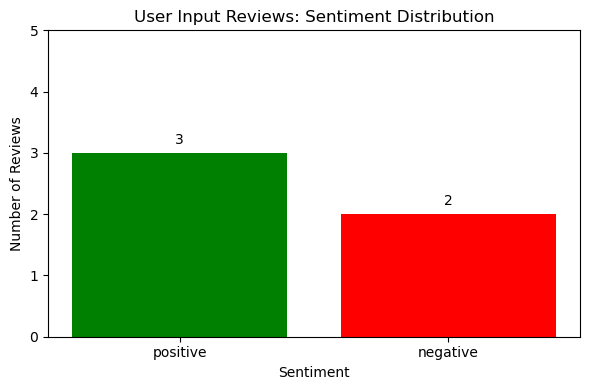

In [42]:
if user_predictions:
    sentiment_counts = pd.Series(user_predictions).value_counts()

    plt.figure(figsize=(6, 4))
    colors = ['Green' if label == 'positive' else 'Red' for label in sentiment_counts.index]
    bars = plt.bar(sentiment_counts.index, sentiment_counts.values, color=colors)

    plt.title('User Input Reviews: Sentiment Distribution')
    plt.xlabel('Sentiment')
    plt.ylabel('Number of Reviews')
    plt.ylim(0, max(sentiment_counts.values) + 2)

    
    for bar in bars:
        height = bar.get_height()
        # text parmeters : x , y , value to display , display modifications : ie., horizontal aligment , vertical alignment 
        plt.text(bar.get_x() + bar.get_width() / 2, height + 0.1, f'{int(height)}', ha='center', va='bottom')

    plt.tight_layout()
    plt.show()
else:
    print("No reviews were entered.")